## 量价择时+ff3_residual_volatility_nm因子的组合策略测试

我们首先先直观的感受一下ff3_residual_volatility_nm因子本身的效果以及其单独在市值分组回测中的表现

[因子基础指标] [7/7] 绘制并展示IC/RankIC时序图 | 已耗时 31.9s-26 | 已耗时 31.8s

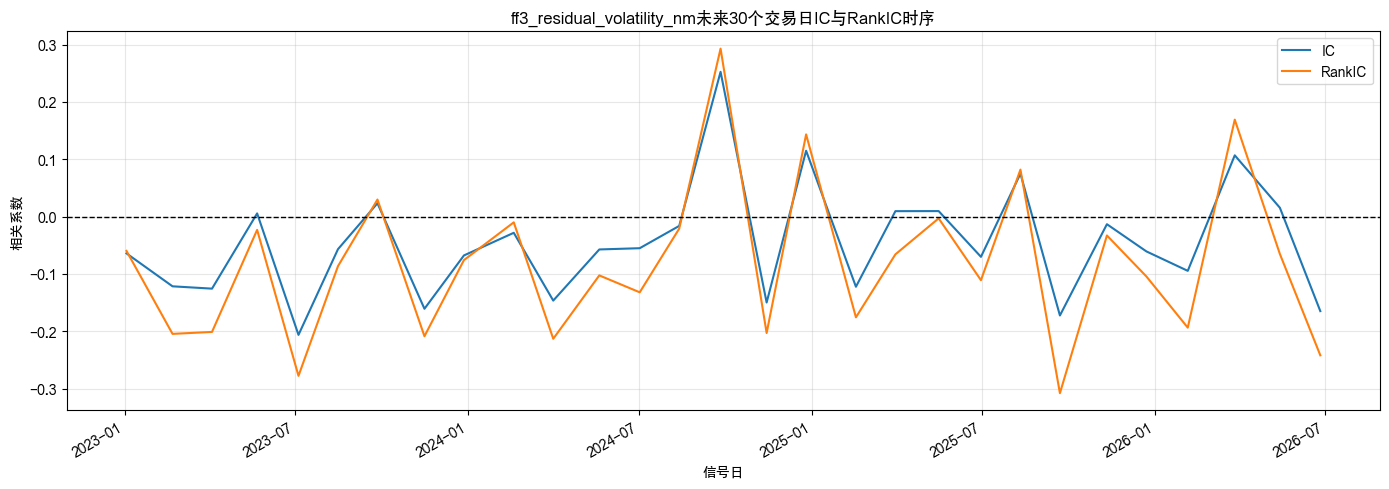

,factor_column,ic_mean,icir,rank_ic_mean,rank_icir,factor_return_mean,mean_t_value,cross_section_count,valid_ic_count
0,ff3_residual_volatility_nm,-0.046387,-0.460092,-0.082985,-0.60128,-0.005046,-3.351375,29,29


,signal_date,return_end_date,sample_count,ic,rank_ic,factor_return,factor_t_value
0,2023-01-03,2023-02-21,4832,-0.064231,-0.059880,-0.008649,-4.473194
1,2023-02-21,2023-04-04,4882,-0.121694,-0.204629,-0.017739,-8.564798
2,2023-04-04,2023-05-22,4937,-0.125747,-0.201218,-0.017186,-8.904326
3,2023-05-22,2023-07-05,4954,0.005463,-0.023275,0.000656,0.384407
4,2023-07-05,2023-08-16,5028,-0.206376,-0.277815,-0.024541,-14.952745
5,2023-08-16,2023-09-27,5053,-0.056933,-0.086564,-0.006792,-4.052817
6,2023-09-27,2023-11-16,5082,0.023165,0.029640,0.003093,1.651473
7,2023-11-16,2023-12-28,5141,-0.160851,-0.208752,-0.033531,-11.683057
8,2023-12-28,2024-02-19,5182,-0.067837,-0.075971,-0.010345,-4.893637
9,2024-02-19,2024-04-01,5255,-0.028370,-0.010144,-0.005232,-2.056988


In [2]:
from IPython.display import display

from factor_lib.function.bigquant_function.factor_evaluation.calculate_factor_basic_metrics import (
    calculate_factor_basic_metrics,
)

# =====================================================
# 参数区
# =====================================================

START_DATE = "2023-01-01"
END_DATE = "2026-08-31"

# =====================================================
# FF3 残差波动率：36 个月窗口
# 每 20 个交易日一个截面，标签为未来 20 日累计收益
# =====================================================

ff3_result = calculate_factor_basic_metrics(
    start_date=START_DATE,
    end_date=END_DATE,
    frequency=30,
    factor_name="ff3_residual_volatility_nm",
    factor_params={
        "n_months": 36,
        "trading_days_per_month": 21,
        "market_index": "csi_all_share",
    },
    universe="all_a",
    min_obs=30,
    plot=True,
    show_progress=True,
    progress_every=30,
)

# 基础指标汇总
ff3_basic_metrics = ff3_result["summary"]
display(ff3_basic_metrics)

# 每个截面的 IC、RankIC、样本数与收益标签终止日
ff3_ic_rankic_timeseries = ff3_result["timeseries"]
display(ff3_ic_rankic_timeseries)

In [4]:
from IPython.display import display

from factor_lib.function.bigquant_function.strategies.market_cap_group_backtest import (
    run_market_cap_group_backtest,
)

# =====================================================
# 1. 回测参数
# =====================================================
START_DATE = "2023-01-01"
END_DATE = "2026-08-31"

# 每 30 个交易日调仓；信号日收盘后计算，下一交易日开盘执行。
REBALANCE_INTERVAL = 30

# 全 A 股按信号日总市值分为 15 个等数量组：
# 1 是最小市值组，15 是最大市值组。
MARKET_CAP_GROUP_COUNT = 15
SELECTED_MARKET_CAP_GROUPS = [1, 2, 3]

# 残差波动率的低波动假设：每个市值组内选因子值最低的 10%。
# 若要检验高残差波动率组合，可改为 (0.9, 1.0)。
FACTOR_QUANTILE_RANGE = (0.0, 0.1)

# =====================================================
# 2. 因子参数：FF3 残差波动率，n = 36 个月
# =====================================================
FACTOR_PARAMS = {
    "n_months": 36,
    "trading_days_per_month": 21,
    "market_index": "csi_all_share",
}

# =====================================================
# 3. 调用统一市值分组回测函数
# =====================================================
ff3_residual_volatility_backtest = run_market_cap_group_backtest(
    start_date=START_DATE,
    end_date=END_DATE,
    rebalance_interval=REBALANCE_INTERVAL,
    universe={"type": "all_a"},
    factor_name="ff3_residual_volatility_nm",
    factor_params=FACTOR_PARAMS,
    market_cap_group_count=MARKET_CAP_GROUP_COUNT,
    selected_market_cap_groups=SELECTED_MARKET_CAP_GROUPS,
    factor_quantile_range=FACTOR_QUANTILE_RANGE,
    order_price_field_buy="open",
    order_price_field_sell="open",
    initial_cash=1_000_000,
    benchmark="000300.SH",
    trading_costs={
        "buy_cost": 0.0003,
        "sell_cost": 0.0003,
        "min_cost": 5.0,
        "tax_ratio": 0.0005,
    },
    slippage_value=0.001,
    volume_limit=0.025,
    show_progress=True,
    progress_every=5,
)

# 输出每个调仓日的目标持仓股票数量。
# target_count 是当期根据信号、市值组与分位筛选后生成的目标持仓数。
rebalance_holding_counts = (
    ff3_residual_volatility_backtest["rebalance_audit"][
        [
            "rebalance_number",
            "signal_date",
            "execution_date",
            "status",
            "candidate_count",
            "eligible_count",
            "target_count",
        ]
    ]
    .rename(
        columns={
            "rebalance_number": "调仓序号",
            "signal_date": "信号日",
            "execution_date": "执行日",
            "status": "信号状态",
            "candidate_count": "截面股票数",
            "eligible_count": "有效股票数",
            "target_count": "目标持仓股票数",
        }
    )
    .sort_values("调仓序号")
    .reset_index(drop=True)
)

display(rebalance_holding_counts)

# 最后一行展示 BigQuant 原生回测结果。
ff3_residual_volatility_backtest["performance"]

[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 8,044,153 行 | 已耗时 4.5s                                                                                                                                                     
[BigQuant 市场日频适配器] [3/3] 市场日频数据准备完成 | 1,649 行 | 已耗时 0.1s                                                                                                                           
[BigQuant loader] 2/2（100.00%），数据域合并完成，当前 market_daily，1,649 行，耗时 7.2s                                                                                                             
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 160,710 行 | 已耗时 2.4s                                                                                                                                                       
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 160,732 行 | 已耗时 2.3s                                                                                                                                 

[2026-09-18 14:51:14] [info     ] bigtrader.v35 运行完成 [123.036s].
[市值分组回测] [8/8] 回测与审计结果整理完成 | 1/1 (100.0%) | 信号3,100条，订单5,090条，成交2,528条 | 已耗时 146.2s                                                                                                                                         


,调仓序号,信号日,执行日,信号状态,截面股票数,有效股票数,目标持仓股票数
0,1,2022-12-30,2023-01-03,ok,5067,4670,96
1,2,2023-02-20,2023-02-21,ok,5093,4756,96
2,3,2023-04-03,2023-04-04,ok,5132,4840,99
3,4,2023-05-19,2023-05-22,ok,5183,4826,99
4,5,2023-07-04,2023-07-05,ok,5226,4905,99
5,6,2023-08-15,2023-08-16,ok,5252,4935,99
6,7,2023-09-26,2023-09-27,ok,5284,4971,102
7,8,2023-11-15,2023-11-16,ok,5306,5036,102
8,9,2023-12-27,2023-12-28,ok,5332,5076,102
9,10,2024-02-08,2024-02-19,ok,5351,5147,105


{'raw_perf': dai.DataSource("_3e4c49286a7b47bca6eb09be62e3d0f0"), 'order_price_field_buy': 'open', 'order_price_field_sell': 'open', 'plot_charts': True, 'start_date': '2022-12-30', 'end_date': '2026-08-31', 'capital_base': 1000000.0, 'instruments': None, 'frequency': '1d', 'benchmark': '000300.SH', 'product_type': 'equity', 'before_start_days': 0, 'volume_limit': 0.025, 'benchmark_data': None, 'basic_data': None, 'dominant_data': None, 'options_data': None, 'debug': False, 'perf_round_num': 4, 'strategy_name': None, 'run_begin_time': '2026-09-18 14:49:11', 'run_mode': 'backtest', 'run_engine': 'py', 'render': <bound method render of {...}>, 'display': <bound method render of {...}>, 'read_raw_perf': <bound method read_raw_perf of {...}>, 'analyze_pnl_per_trade': <bound method analyze_pnl_per_trade of {...}>, 'analyze_pnl_per_day': <bound method analyze_pnl_per_day of {...}>, 'plot_return_curve_per_stock': <bound method plot_return_curve_per_stock of {...}>, 'plot_curve_return': <bound

通过上述的检验已经可以看出该因子是有效的，接下来我们检验一下择时因子能为策略带来多大的改善，在第一版测试当中，我们先看看筛掉的股票直接保留现金的结果,第二版的测试当中尝试一下不保留现金会有怎样的结果

In [2]:
# -*- coding: utf-8 -*-
"""FF3 残差波动率市值分组 + 个股价量择时共同筛选的独立回测脚本。

这是一次性研究脚本：不调用、不修改统一市值分组回测函数。
"""

import math
import time
import gc

import numpy as np
import pandas as pd
import dai
from IPython.display import display
from bigquant import bigtrader

from factor_lib.common.data_adapters.bigquant_adapters.daily import (
    load_daily_raw_data,
)
from factor_lib.common.data_adapters.bigquant_adapters.loader import (
    get_factor_data_requirements,
    load_factor_raw_data,
)
from factor_lib.factor_hub.get_factor import get_factor


# =====================================================
# 1. 回测、选股与交易参数
# =====================================================
START_DATE = "2023-01-01"
END_DATE = "2026-08-31"
REBALANCE_INTERVAL = 30

# 全 A 股按信号日总市值分为 15 个近似等数量组；第 1 组最小。
MARKET_CAP_GROUP_COUNT = 15
SELECTED_MARKET_CAP_GROUPS = [1, 2, 3]

# FF3 残差波动率尚未在 FACTOR 元数据中确定方向。本研究检验低波动端。
FACTOR_QUANTILE_RANGE = (0.0, 0.1)
BASE_FACTOR_NAME = "ff3_residual_volatility_nm"
BASE_FACTOR_PARAMS = {
    "n_months": 36,
    "trading_days_per_month": 21,
    "market_index": "csi_all_share",
}

# 个股价量择时共同持仓门槛。默认沿用华泰研报策略三：
# 价格同比上升、成交量同比上升、成交量同比大于 0。
# 可选 strategy_1 / strategy_2 / strategy_3 / strategy_4。
TIMING_RULE = "strategy_3"
PRICE_TIMING_FACTOR_NAME = "stock_price_log_yoy"
VOLUME_TIMING_FACTOR_NAME = "stock_cumulative_volume_log_yoy"

# False：先按基础因子确定等权，再剔除未通过价量择时的股票；被剔除权重留为现金。
# True：剔除后将剩余股票重新等权至 100% 仓位。
# 本次用于测试“保留现金”的版本，默认设为 False。
FULLY_INVESTED_AFTER_TIMING = True

CAPITAL_BASE = 1_000_000
BENCHMARK = "000300.SH"
BUY_COST = 0.0003
SELL_COST = 0.0003
TAX_RATIO = 0.0005
MIN_COST = 5.0
SLIPPAGE_VALUE = 0.001
VOLUME_LIMIT = 0.025

SHOW_PROGRESS = True
# 三类进度分开控制，避免因子循环过密刷屏，同时保留调仓和引擎进度。
REBALANCE_PROGRESS_EVERY = 1
FF3_PROGRESS_EVERY = 5
TIMING_FACTOR_PROGRESS_EVERY = 250
ENGINE_PROGRESS_EVERY = 20


# =====================================================
# 2. 交易日历、调仓日与因子原始数据日期
# =====================================================
started_at = time.perf_counter()
start_ts = pd.Timestamp(START_DATE).normalize()
end_ts = pd.Timestamp(END_DATE).normalize()


def report_stage(stage, detail=""):
    """输出不可细分阶段的起止信息，不参与任何策略计算。"""
    if not SHOW_PROGRESS:
        return
    elapsed = time.perf_counter() - started_at
    message = f"[价量择时市值分组回测] {stage} | 已耗时 {elapsed:.1f}s"
    if detail:
        message += f" | {detail}"
    print(message, flush=True)

if TIMING_RULE not in {"strategy_1", "strategy_2", "strategy_3", "strategy_4"}:
    raise ValueError("TIMING_RULE 仅支持 strategy_1、strategy_2、strategy_3、strategy_4。")
if not 0 <= FACTOR_QUANTILE_RANGE[0] < FACTOR_QUANTILE_RANGE[1] <= 1:
    raise ValueError("FACTOR_QUANTILE_RANGE 必须满足 0 <= lower < upper <= 1。")

if SHOW_PROGRESS:
    print("[价量择时市值分组回测] [1/6] 读取交易日历并生成调仓计划...")

calendar = dai.query(
    f"""
    SELECT DISTINCT date
    FROM cn_stock_bar1d
    WHERE date <= '{end_ts:%Y-%m-%d}'
    ORDER BY date
    """
).df()
calendar["date"] = pd.to_datetime(calendar["date"], errors="coerce").dt.normalize()
trading_calendar = pd.DatetimeIndex(calendar["date"].dropna().drop_duplicates()).sort_values()
report_stage("[1/12] 交易日历读取完成", f"共 {len(trading_calendar)} 个交易日")
execution_dates = trading_calendar[
    (trading_calendar >= start_ts) & (trading_calendar <= end_ts)
][::REBALANCE_INTERVAL]
if len(execution_dates) == 0:
    raise ValueError("回测区间内没有交易日。")

execution_positions = trading_calendar.get_indexer(execution_dates)
if (execution_positions <= 0).any():
    raise ValueError("首次执行日前缺少一个交易日，无法形成前一日收盘信号。")
signal_dates = trading_calendar[execution_positions - 1]
schedule = pd.DataFrame(
    {
        "rebalance_number": np.arange(1, len(execution_dates) + 1),
        "signal_date": signal_dates,
        "execution_date": execution_dates,
    }
)
report_stage(
    "[2/12] 调仓计划生成完成",
    f"{len(schedule)} 次调仓，信号日 {signal_dates.min():%Y-%m-%d} 至 {signal_dates.max():%Y-%m-%d}",
)

# 对月度择时因子，仅使用本回测实际需要的、已经完成的自然月最后一个交易日；
# 不会把月中数据当作月末值，也不会从 2005 年起无谓加载全历史数据。
# 任一信号日使用其当时最近已完成月的择时状态，并额外保留前一个月以计算“上升”。
calendar_frame = pd.DataFrame({"date": trading_calendar})
calendar_frame["month"] = calendar_frame["date"].dt.to_period("M")
all_month_end_dates = pd.DatetimeIndex(
    calendar_frame.groupby("month", sort=True)["date"].max().to_numpy()
)
available_month_end_dates = all_month_end_dates[
    all_month_end_dates <= signal_dates.max()
]
first_current_month_end = available_month_end_dates[
    available_month_end_dates <= signal_dates.min()
].max()
first_current_month_position = available_month_end_dates.get_indexer(
    [first_current_month_end]
)[0]
if first_current_month_position <= 0:
    raise ValueError("回测起点前缺少上一个完整月，无法判断价量同比是否上升。")
month_end_dates = available_month_end_dates[first_current_month_position - 1 :]

base_requirements = get_factor_data_requirements(
    BASE_FACTOR_NAME,
    BASE_FACTOR_PARAMS,
)
base_params = {
    key: value
    for key, value in base_requirements["resolved_factor_params"].items()
    if key not in {"target_dates", "as_of_date", "show_progress", "progress_every"}
}
base_window = base_requirements["data_window"]
base_lookback = max(
    int(base_window.get("lookback_trading_days", 0)),
    int(base_window.get("minimum_history_observations", 0)),
)
first_signal_position = trading_calendar.get_indexer([signal_dates.min()])[0]
if first_signal_position < base_lookback:
    raise ValueError("回测起点前的 FF3 因子预热交易日不足。")
# FF3 只在月度频率上使用股票的收盘价、市值和 PB；信号日额外保留，
# 用于将上一完整月的因子值映射至当期调仓截面。避免为整个日频区间加载数据。
base_history_start = trading_calendar[first_signal_position - base_lookback]
base_month_end_dates = all_month_end_dates[
    (all_month_end_dates >= base_history_start)
    & (all_month_end_dates <= signal_dates.max())
]
base_raw_dates = pd.DatetimeIndex(
    sorted(set(base_month_end_dates).union(set(signal_dates)))
)

timing_requirements = [
    get_factor_data_requirements(PRICE_TIMING_FACTOR_NAME, {}),
    get_factor_data_requirements(VOLUME_TIMING_FACTOR_NAME, {}),
]
timing_lookback = max(
    max(
        int(requirements["data_window"].get("lookback_trading_days", 0)),
        int(requirements["data_window"].get("minimum_history_observations", 0)),
    )
    for requirements in timing_requirements
)
first_timing_position = trading_calendar.get_indexer([month_end_dates.min()])[0]
if first_timing_position < timing_lookback:
    raise ValueError("回测起点前的个股价量择时因子预热交易日不足。")
timing_raw_dates = trading_calendar[
    first_timing_position - timing_lookback : trading_calendar.get_indexer([month_end_dates.max()])[0] + 1
]
report_stage(
    "[3/12] 因子数据日期计划完成",
    (
        f"FF3 稀疏日期 {len(base_raw_dates)} 个；"
        f"价量日频日期 {len(timing_raw_dates)} 个；"
        f"价量预热 {timing_lookback} 个交易日"
    ),
)


# =====================================================
# 3. 计算基础因子、两个月度择时因子及信号日选股状态
# =====================================================
if SHOW_PROGRESS:
    print(
        "[价量择时市值分组回测] [4/12-A] 加载 FF3 残差波动率所需原始数据 | "
        f"稀疏日期 {len(base_raw_dates)} 个（{len(base_month_end_dates)} 个月末 + "
        f"{len(signal_dates)} 个信号日，去重后）..."
    )

base_raw_bundle = load_factor_raw_data(
    factor_name=BASE_FACTOR_NAME,
    dates=base_raw_dates,
    factor_params=base_params,
    instruments=None,
    show_progress=SHOW_PROGRESS,
)
report_stage("[4/12-B] FF3 原始数据加载完成，开始计算因子")
base_factor_panel = get_factor(
    BASE_FACTOR_NAME,
    base_raw_bundle,
    target_dates=signal_dates,
    as_of_date=signal_dates.max(),
    show_progress=SHOW_PROGRESS,
    progress_every=FF3_PROGRESS_EVERY,
    **base_params,
)
report_stage("[4/12-C] FF3 因子计算完成", f"输出 {len(base_factor_panel):,} 行，释放原始数据")
# FF3 原始包有数百万行；因子面板生成后立即释放，避免与后续择时数据叠加。
del base_raw_bundle
gc.collect()

if SHOW_PROGRESS:
    print(
        "[价量择时市值分组回测] [5/12-A] 加载价格同比所需日频数据 | "
        f"{timing_raw_dates.min():%Y-%m-%d} 至 {timing_raw_dates.max():%Y-%m-%d}..."
    )

price_raw_bundle = load_factor_raw_data(
    factor_name=PRICE_TIMING_FACTOR_NAME,
    dates=timing_raw_dates,
    factor_params={},
    instruments=None,
    show_progress=SHOW_PROGRESS,
)
report_stage("[5/12-B] 价格同比原始数据加载完成，开始计算因子")
price_timing_panel = get_factor(
    PRICE_TIMING_FACTOR_NAME,
    price_raw_bundle,
    target_dates=month_end_dates,
    as_of_date=signal_dates.max(),
    show_progress=SHOW_PROGRESS,
    progress_every=TIMING_FACTOR_PROGRESS_EVERY,
)
report_stage("[5/12-C] 价格同比因子计算完成", f"输出 {len(price_timing_panel):,} 行，释放原始数据")
# 两个择时因子按顺序计算，绝不同时保留两个日频原始包。
del price_raw_bundle
gc.collect()

if SHOW_PROGRESS:
    print("[价量择时市值分组回测] [6/12-A] 加载累计成交量同比所需日频数据...")

volume_raw_bundle = load_factor_raw_data(
    factor_name=VOLUME_TIMING_FACTOR_NAME,
    dates=timing_raw_dates,
    factor_params={},
    instruments=None,
    show_progress=SHOW_PROGRESS,
)
report_stage("[6/12-B] 累计成交量原始数据加载完成，开始计算因子")
volume_timing_panel = get_factor(
    VOLUME_TIMING_FACTOR_NAME,
    volume_raw_bundle,
    target_dates=month_end_dates,
    as_of_date=signal_dates.max(),
    show_progress=SHOW_PROGRESS,
    progress_every=TIMING_FACTOR_PROGRESS_EVERY,
)
report_stage("[6/12-C] 累计成交量同比计算完成", f"输出 {len(volume_timing_panel):,} 行，释放原始数据")
del volume_raw_bundle
gc.collect()

# 信号日状态用于原市值分组股票池；执行日状态只用于执行约束，二者不混用。
if SHOW_PROGRESS:
    print("[价量择时市值分组回测] [7/12-A] 读取信号日股票状态...")

signal_state = load_daily_raw_data(
    ["total_market_cap", "is_risk_warning", "suspended", "volume"],
    dates=signal_dates,
    instruments=None,
    show_progress=SHOW_PROGRESS,
)
report_stage("[7/12-B] 信号日股票状态读取完成", f"{len(signal_state):,} 行，开始读取执行日状态")
execution_state = load_daily_raw_data(
    [
        "is_risk_warning",
        "suspended",
        "volume",
        "open",
        "upper_limit",
        "lower_limit",
    ],
    dates=execution_dates,
    instruments=None,
    show_progress=SHOW_PROGRESS,
)
report_stage("[7/12-C] 执行日股票状态读取完成", f"{len(execution_state):,} 行")

if SHOW_PROGRESS:
    print("[价量择时市值分组回测] [8/12-A] 校验因子与交易状态数据主键...")
for panel_name, panel in {
    "base_factor_panel": base_factor_panel,
    "price_timing_panel": price_timing_panel,
    "volume_timing_panel": volume_timing_panel,
    "signal_state": signal_state,
    "execution_state": execution_state,
}.items():
    panel["date"] = pd.to_datetime(panel["date"], errors="coerce").dt.normalize()
    panel["instrument"] = panel["instrument"].astype(str)
    if panel["date"].isna().any() or panel.duplicated(["date", "instrument"], keep=False).any():
        raise ValueError(f"{panel_name} 存在无效日期或重复 date + instrument。")

report_stage("[8/12-B] 数据主键校验完成，开始合并两项择时因子")

timing_panel = price_timing_panel.merge(
    volume_timing_panel,
    on=["date", "instrument"],
    how="outer",
    validate="one_to_one",
).sort_values(["instrument", "date"], kind="mergesort")
report_stage("[8/12-C] 择时因子合并完成", f"{len(timing_panel):,} 行，开始计算环比上升条件")
timing_panel["price_yoy_previous"] = timing_panel.groupby("instrument", sort=False)[
    PRICE_TIMING_FACTOR_NAME
].shift(1)
timing_panel["volume_yoy_previous"] = timing_panel.groupby("instrument", sort=False)[
    VOLUME_TIMING_FACTOR_NAME
].shift(1)

price_up = timing_panel[PRICE_TIMING_FACTOR_NAME] > timing_panel["price_yoy_previous"]
volume_up = timing_panel[VOLUME_TIMING_FACTOR_NAME] > timing_panel["volume_yoy_previous"]
price_positive = timing_panel[PRICE_TIMING_FACTOR_NAME] > 0
volume_positive = timing_panel[VOLUME_TIMING_FACTOR_NAME] > 0
if TIMING_RULE == "strategy_1":
    timing_panel["timing_pass"] = price_up & price_positive
elif TIMING_RULE == "strategy_2":
    timing_panel["timing_pass"] = volume_up & volume_positive
elif TIMING_RULE == "strategy_3":
    timing_panel["timing_pass"] = price_up & volume_up & volume_positive
else:
    timing_panel["timing_pass"] = price_up & price_positive & volume_up & volume_positive
timing_panel["timing_pass"] = timing_panel["timing_pass"].fillna(False)
report_stage(
    "[8/12-D] 择时条件计算完成",
    f"通过记录 {int(timing_panel['timing_pass'].sum()):,} 条 / {len(timing_panel):,} 条",
)


# =====================================================
# 4. 先复现市值分组和基础因子选股，再施加共同持仓筛选
# =====================================================
base_factor_column = BASE_FACTOR_NAME
selection_panel = signal_state.merge(
    base_factor_panel[["date", "instrument", base_factor_column]],
    on=["date", "instrument"],
    how="left",
    validate="one_to_one",
)
for column in ["total_market_cap", "is_risk_warning", "suspended", "volume", base_factor_column]:
    selection_panel[column] = pd.to_numeric(selection_panel[column], errors="coerce")

selection_records = []
audit_records = []
quantile_lower, quantile_upper = FACTOR_QUANTILE_RANGE

if SHOW_PROGRESS:
    print("[价量择时市值分组回测] [9/12] 构造市值分组和价量筛选后的调仓目标...")

for position, schedule_row in enumerate(schedule.itertuples(index=False), start=1):
    signal_date = schedule_row.signal_date
    execution_date = schedule_row.execution_date
    cross_section = selection_panel.loc[
        selection_panel["date"] == signal_date,
        ["instrument", "total_market_cap", "is_risk_warning", "suspended", "volume", base_factor_column],
    ].copy()
    candidate_count = len(cross_section)
    cross_section["eligible"] = (
        cross_section["total_market_cap"].gt(0)
        & cross_section["is_risk_warning"].fillna(1).eq(0)
        & cross_section["suspended"].fillna(1).eq(0)
        & cross_section["volume"].fillna(0).gt(0)
        & cross_section[base_factor_column].notna()
        & np.isfinite(cross_section[base_factor_column])
    )
    eligible = cross_section.loc[cross_section["eligible"]].copy()
    eligible = eligible.sort_values(["total_market_cap", "instrument"], kind="mergesort").reset_index(drop=True)
    eligible_count = len(eligible)
    selected_parts = []
    group_populations = {}
    selected_counts = {}

    if eligible_count:
        actual_group_count = min(MARKET_CAP_GROUP_COUNT, eligible_count)
        eligible["market_cap_rank"] = np.arange(1, eligible_count + 1)
        eligible["market_cap_group"] = (
            pd.qcut(eligible["market_cap_rank"], q=actual_group_count, labels=False).astype(int) + 1
        )
        for group_number in range(1, actual_group_count + 1):
            group = eligible.loc[eligible["market_cap_group"] == group_number].copy()
            group = group.sort_values([base_factor_column, "instrument"], kind="mergesort").reset_index(drop=True)
            group_populations[group_number] = len(group)
            selected = group.iloc[0:0].copy()
            if group_number in SELECTED_MARKET_CAP_GROUPS:
                start_index = int(math.floor(len(group) * quantile_lower))
                end_index = min(len(group), max(int(math.ceil(len(group) * quantile_upper)), start_index + 1))
                selected = group.iloc[start_index:end_index].copy()
                selected["factor_quantile"] = (np.arange(start_index + 1, end_index + 1) / len(group))
                if not selected.empty:
                    selected_parts.append(selected)
            selected_counts[group_number] = len(selected)
        base_selected = pd.concat(selected_parts, ignore_index=True) if selected_parts else eligible.iloc[0:0].copy()
    else:
        actual_group_count = 0
        base_selected = eligible.copy()

    # 基础市值分组组合的原始全局等权。在“保留现金”模式下，后续价量筛选
    # 仅删除股票，不改变通过股票的这份原始权重。
    if not base_selected.empty:
        base_selected["base_target_weight"] = 1.0 / len(base_selected)

    # 调仓日不是月末时，使用其之前最近一个完整月的价量指标；绝不倒填未来月度值。
    latest_timing = timing_panel.loc[timing_panel["date"] <= signal_date].sort_values(
        ["instrument", "date"], kind="mergesort"
    ).groupby("instrument", sort=False).tail(1)
    final_selected = base_selected.merge(
        latest_timing[
            [
                "instrument",
                "date",
                PRICE_TIMING_FACTOR_NAME,
                "price_yoy_previous",
                VOLUME_TIMING_FACTOR_NAME,
                "volume_yoy_previous",
                "timing_pass",
            ]
        ].rename(columns={"date": "timing_date"}),
        on="instrument",
        how="left",
        validate="one_to_one",
    )
    final_selected["timing_pass"] = final_selected["timing_pass"].fillna(False)
    final_selected = final_selected.loc[final_selected["timing_pass"]].copy()
    final_selected = final_selected.drop_duplicates("instrument").reset_index(drop=True)
    if not final_selected.empty:
        if FULLY_INVESTED_AFTER_TIMING:
            # 通过择时的股票重新等权，目标权重之和为 100%。
            final_selected["target_weight"] = 1.0 / len(final_selected)
        else:
            # 保留基础组合的原始权重；择时淘汰股票对应的资金保留为现金。
            final_selected["target_weight"] = final_selected["base_target_weight"]
        final_selected["rebalance_number"] = schedule_row.rebalance_number
        final_selected["signal_date"] = signal_date
        final_selected["execution_date"] = execution_date
        selection_records.extend(final_selected.to_dict("records"))

    audit_records.append(
        {
            "rebalance_number": schedule_row.rebalance_number,
            "signal_date": signal_date,
            "execution_date": execution_date,
            "candidate_count": candidate_count,
            "eligible_count": eligible_count,
            "actual_group_count": actual_group_count,
            "group_populations": group_populations,
            "base_selected_count": len(base_selected),
            "timing_pass_count": len(final_selected),
            "target_count": len(final_selected),
            "target_weight_sum": (
                float(final_selected["target_weight"].sum())
                if not final_selected.empty
                else 0.0
            ),
            "selected_counts": selected_counts,
        }
    )
    if SHOW_PROGRESS and (
        position == 1 or position % REBALANCE_PROGRESS_EVERY == 0 or position == len(schedule)
    ):
        elapsed = time.perf_counter() - started_at
        eta = elapsed / position * (len(schedule) - position)
        print(
            f"\r[价量择时市值分组回测] [9/12] {position}/{len(schedule)} "
            f"({position / len(schedule):.1%}) | 信号日 {signal_date:%Y-%m-%d} | "
            f"基础入选 {len(base_selected)} 只 | 择时后 {len(final_selected)} 只 | "
            f"已耗时 {elapsed:.1f}s | 预计剩余 {eta:.1f}s".ljust(180),
            end="",
            flush=True,
        )
if SHOW_PROGRESS:
    print()

report_stage("[9/12] 调仓目标构造完成", f"共处理 {len(schedule)} 次调仓")

targets = pd.DataFrame(selection_records)
rebalance_audit = pd.DataFrame(audit_records)
if targets.empty:
    targets = pd.DataFrame(
        columns=[
            "rebalance_number", "signal_date", "execution_date", "instrument",
            "target_weight", "market_cap_group", base_factor_column,
        ]
    )
else:
    targets = targets.sort_values(
        ["execution_date", "target_weight", "instrument"],
        ascending=[True, False, True],
        kind="mergesort",
    ).reset_index(drop=True)
    targets["target_rank"] = targets.groupby("execution_date").cumcount() + 1

# 仅当没有任何股票通过共同筛选时，才写入现金信号以触发清仓。
cash_execution_dates = set(targets["execution_date"]) if not targets.empty else set()
cash_signals = schedule.loc[~schedule["execution_date"].isin(cash_execution_dates)].copy()
cash_signals["instrument"] = "__CASH_SIGNAL__"
cash_signals["target_weight"] = 0.0
cash_signals["target_rank"] = 0
cash_signals["is_cash_signal"] = True

if not targets.empty:
    targets["is_cash_signal"] = False
    signal_df = pd.concat(
        [
            targets[["rebalance_number", "signal_date", "execution_date", "instrument", "target_weight", "target_rank", "is_cash_signal"]],
            cash_signals[["rebalance_number", "signal_date", "execution_date", "instrument", "target_weight", "target_rank", "is_cash_signal"]],
        ],
        ignore_index=True,
    )
else:
    signal_df = cash_signals[["rebalance_number", "signal_date", "execution_date", "instrument", "target_weight", "target_rank", "is_cash_signal"]].copy()
signal_df = signal_df.rename(columns={"execution_date": "date"})
signal_df["date"] = pd.to_datetime(signal_df["date"]).dt.strftime("%Y-%m-%d")
signal_df["signal_date"] = pd.to_datetime(signal_df["signal_date"]).dt.strftime("%Y-%m-%d")
signal_df = signal_df.sort_values(["date", "is_cash_signal", "target_rank", "instrument"], kind="mergesort").reset_index(drop=True)
report_stage("[10/12-A] 订单信号表构造完成", f"{len(signal_df):,} 条信号记录")

engine_instruments = sorted(targets["instrument"].unique()) if not targets.empty else []
if not engine_instruments:
    raise ValueError("所有调仓期均没有同时通过市值分组和价量择时筛选的股票。")

# 执行日状态只在订单提交时使用，不会影响前一日的市值分组或信号形成。
for column in ["is_risk_warning", "suspended", "volume", "open", "upper_limit", "lower_limit"]:
    execution_state[column] = pd.to_numeric(execution_state[column], errors="coerce")
execution_state_map = execution_state.set_index(["date", "instrument"])[
    ["is_risk_warning", "suspended", "volume", "open", "upper_limit", "lower_limit"]
].to_dict("index")
report_stage("[10/12-B] 执行日交易状态索引构造完成", f"{len(execution_state_map):,} 个日期-股票状态")

print(
    "[价量择时市值分组回测] [10/12-C] 调仓目标准备完成："
    f"{len(schedule)} 次调仓，择时规则 {TIMING_RULE}，"
    f"涉及 {len(engine_instruments)} 只目标股票。"
)


# =====================================================
# 5. BigTrader 原生回测：失效持仓在调仓日目标权重归零
# =====================================================
def initialize(context: bigtrader.IContext):
    context.signal_data = context.data.copy()
    context.signal_dates = set(context.signal_data["date"].astype(str).unique())
    context.completed_rebalances = 0
    context.processed_engine_days = 0
    context.last_engine_progress_date = None
    context.engine_started_at = time.perf_counter()
    context.total_engine_days = len(engine_trading_dates)
    context.set_commission(
        bigtrader.PerOrder(
            buy_cost=BUY_COST,
            sell_cost=SELL_COST,
            min_cost=MIN_COST,
            tax_ratio=TAX_RATIO,
        )
    )
    context.set_slippage_value(slippage_type=2, slippage_value=SLIPPAGE_VALUE)


def handle_data(context: bigtrader.IContext, data: bigtrader.IBarData):
    today = data.current_dt.strftime("%Y-%m-%d")
    if context.last_engine_progress_date != today:
        context.processed_engine_days += 1
        context.last_engine_progress_date = today
    is_rebalance_day = today in context.signal_dates

    # 引擎逐日运行时也显示节流后的进度，避免两个调仓日之间看似“静默”。
    if SHOW_PROGRESS and (
        context.processed_engine_days == 1
        or context.processed_engine_days % ENGINE_PROGRESS_EVERY == 0
        or context.processed_engine_days == context.total_engine_days
    ) and not is_rebalance_day:
        elapsed = time.perf_counter() - context.engine_started_at
        completed = context.processed_engine_days
        total = context.total_engine_days
        eta = elapsed / completed * (total - completed) if completed else np.nan
        print(
            "[价量择时市值分组回测] [11/12] BigTrader 日频推进 | "
            f"{completed}/{total} ({completed / total:.1%}) | 当前 {today} | "
            f"已耗时 {elapsed:.1f}s | 预计剩余 {eta:.1f}s"
        )

    if not is_rebalance_day:
        return

    today_signal = context.signal_data.loc[context.signal_data["date"] == today].copy()
    today_targets = today_signal.loc[~today_signal["is_cash_signal"]].copy()
    target_weight_map = dict(zip(today_targets["instrument"], today_targets["target_weight"]))
    execution_date = pd.Timestamp(today).normalize()

    # 根据账户当前市值估算实际权重，以区分加仓（涨停不可买）和减仓
    # （跌停不可卖）。不会用上一期的“目标权重”冒充实际成交权重。
    positions = context.get_positions()
    portfolio_value = getattr(getattr(context, "portfolio", None), "portfolio_value", np.nan)
    try:
        portfolio_value = float(portfolio_value)
    except (TypeError, ValueError):
        portfolio_value = np.nan
    current_weight_map = {}
    if np.isfinite(portfolio_value) and portfolio_value > 0:
        for instrument, position in positions.items():
            quantity = next(
                (
                    float(getattr(position, field))
                    for field in ("current_qty", "amount", "quantity")
                    if getattr(position, field, None) is not None
                ),
                0.0,
            )
            price = next(
                (
                    float(getattr(position, field))
                    for field in ("last_price", "last_sale_price", "market_price", "cost_price")
                    if getattr(position, field, None) is not None
                    and np.isfinite(float(getattr(position, field)))
                    and float(getattr(position, field)) > 0
                ),
                np.nan,
            )
            if quantity > 0 and np.isfinite(price):
                current_weight_map[instrument] = quantity * price / portfolio_value

    all_instruments = sorted(set(current_weight_map).union(target_weight_map))
    sell_intents = []
    buy_intents = []
    for instrument in all_instruments:
        current_weight = float(current_weight_map.get(instrument, 0.0))
        target_weight = float(target_weight_map.get(instrument, 0.0))
        if abs(target_weight - current_weight) <= 1e-4:
            continue
        if target_weight < current_weight:
            sell_intents.append((instrument, target_weight))
        else:
            buy_intents.append((instrument, target_weight))

    # 先卖出：其中包括未入选市值分组和价量择时条件失效的历史持仓。
    for instrument, target_weight in sell_intents:
        state = execution_state_map.get((execution_date, instrument))
        if state is None:
            continue
        can_trade = (
            state["suspended"] == 0
            and state["volume"] > 0
            and state["open"] > state["lower_limit"]
        )
        if can_trade:
            context.order_target_percent(instrument, float(target_weight))

    # 后买入/加仓：FULLY_INVESTED_AFTER_TIMING=False 时，择时淘汰的权重
    # 按策略定义保留为现金；其他现金只可能来自涨停、停牌或 ST 的执行约束。
    for instrument, target_weight in buy_intents:
        state = execution_state_map.get((execution_date, instrument))
        if state is None:
            continue
        can_trade = (
            state["is_risk_warning"] == 0
            and state["suspended"] == 0
            and state["volume"] > 0
            and state["open"] < state["upper_limit"]
        )
        if can_trade:
            context.order_target_percent(instrument, float(target_weight))

    context.completed_rebalances += 1
    if SHOW_PROGRESS and (
        context.completed_rebalances == 1
        or context.completed_rebalances % REBALANCE_PROGRESS_EVERY == 0
        or context.completed_rebalances == len(schedule)
    ):
        elapsed = time.perf_counter() - context.engine_started_at
        completed = context.processed_engine_days
        total = context.total_engine_days
        eta = elapsed / completed * (total - completed) if completed else np.nan
        first = today_signal.iloc[0]
        print(
            "[价量择时市值分组回测] [11/12] BigTrader 调仓执行 | "
            f"调仓 {context.completed_rebalances}/{len(schedule)} | 执行日 {today} | "
            f"信号日 {first['signal_date']} | 目标持仓 {len(today_targets)} 只 | "
            f"日频进度 {completed}/{total} | 已耗时 {elapsed:.1f}s | 预计剩余 {eta:.1f}s"
        )


if SHOW_PROGRESS:
    print("[价量择时市值分组回测] [11/12] 启动 BigTrader 原生回测...")

engine_start_date = pd.Timestamp(signal_df["date"].min()).normalize()
engine_trading_dates = trading_calendar[
    (trading_calendar >= engine_start_date) & (trading_calendar <= end_ts)
]
report_stage(
    "[11/12-A] BigTrader 数据准备完成",
    f"回测日 {len(engine_trading_dates)} 个，标的 {len(engine_instruments)} 只",
)

performance = bigtrader.run(
    market=bigtrader.Market.CN_STOCK,
    frequency=bigtrader.Frequency.DAILY,
    start_date=engine_start_date.strftime("%Y-%m-%d"),
    end_date=END_DATE,
    capital_base=CAPITAL_BASE,
    instruments=engine_instruments,
    data=signal_df,
    initialize=initialize,
    handle_data=handle_data,
    benchmark=BENCHMARK,
    order_price_field_buy="open",
    order_price_field_sell="open",
    volume_limit=VOLUME_LIMIT,
)
report_stage("[12/12] BigTrader 回测完成，开始整理审计结果")

# 每期“目标持仓股票数”、筛选过程及目标权重和。
# 当前保留现金模式下，目标权重合计可以小于 1.0。
rebalance_holding_counts = rebalance_audit[
    [
        "rebalance_number", "signal_date", "execution_date", "candidate_count",
        "eligible_count", "base_selected_count", "timing_pass_count", "target_count",
        "target_weight_sum",
    ]
].rename(
    columns={
        "rebalance_number": "调仓序号",
        "signal_date": "信号日",
        "execution_date": "执行日",
        "candidate_count": "截面股票数",
        "eligible_count": "市值分组有效股票数",
        "base_selected_count": "基础因子入选数",
        "timing_pass_count": "价量择时通过数",
        "target_count": "目标持仓股票数",
        "target_weight_sum": "目标权重合计",
    }
)
display(rebalance_holding_counts)

# Notebook 最后一行展示 BigQuant 原生回测结果。
display(performance)


[价量择时市值分组回测] [1/6] 读取交易日历并生成调仓计划...
[价量择时市值分组回测] [1/12] 交易日历读取完成 | 已耗时 0.2s | 共 5261 个交易日
[价量择时市值分组回测] [2/12] 调仓计划生成完成 | 已耗时 0.2s | 30 次调仓，信号日 2022-12-30 至 2026-08-06
[价量择时市值分组回测] [3/12] 因子数据日期计划完成 | 已耗时 0.2s | FF3 稀疏日期 110 个；价量日频日期 1429 个；价量预热 540 个交易日
[价量择时市值分组回测] [4/12-A] 加载 FF3 残差波动率所需原始数据 | 稀疏日期 110 个（82 个月末 + 30 个信号日，去重后）...
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 550,444 行 | 已耗时 1.4s                                                                                                               
[BigQuant 市场日频适配器] [3/3] 市场日频数据准备完成 | 110 行 | 已耗时 1.3s                                                                                                                             
[BigQuant loader] 2/2（100.00%），数据域合并完成，当前 market_daily，110 行，耗时 4.3s                                                                                                               
[价量择时市值分组回测] [4/12-B] FF3 原始数据加载完成，开始计算因子 | 已耗时 4.7s
[ff3_residual_volatility_nm] [7/7 回归残差波动率] 5771/5771 (100.0%) | 已耗时 14.9s

[2026-09-18 17:08:24] [info     ] bigtrader run done.
[价量择时市值分组回测] [12/12] BigTrader 回测完成，开始整理审计结果 | 已耗时 148.7s


,调仓序号,信号日,执行日,截面股票数,市值分组有效股票数,基础因子入选数,价量择时通过数,目标持仓股票数,目标权重合计
0,1,2022-12-30,2023-01-03,5067,4670,96,1,1,1.0
1,2,2023-02-20,2023-02-21,5093,4756,96,8,8,1.0
2,3,2023-04-03,2023-04-04,5132,4840,99,3,3,1.0
3,4,2023-05-19,2023-05-22,5183,4826,99,3,3,1.0
4,5,2023-07-04,2023-07-05,5226,4905,99,2,2,1.0
5,6,2023-08-15,2023-08-16,5252,4935,99,3,3,1.0
6,7,2023-09-26,2023-09-27,5284,4971,102,5,5,1.0
7,8,2023-11-15,2023-11-16,5306,5036,102,1,1,1.0
8,9,2023-12-27,2023-12-28,5332,5076,102,7,7,1.0
9,10,2024-02-08,2024-02-19,5351,5147,105,0,0,0.0


## 结论

无论是保留或是不保留现金，目前这份择时因子的效果都不尽人意